# Behavior-Aware Explainable Fraud Detection System
This notebook runs an end-to-end fraud detection pipeline featuring behavioral risk scoring, anomaly detection, and explainability.

In [ ]:
# Install required packages in Google Colab
!pip install -q xgboost scikit-learn imbalanced-learn shap pandas numpy matplotlib seaborn joblib kagglehub

## 1. System Configuration & Setup

In [57]:
import os
import sys
import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42

# Directories setup
BASE_DIR = Path(os.getcwd()).resolve()
DATA_DIR = BASE_DIR / 'data'
MODEL_DIR = BASE_DIR / 'models'
REPORT_DIR = BASE_DIR / 'reports'
PLOT_DIR = REPORT_DIR / 'plots'

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('Environment set up successfully.')

# Detect environment to prevent local Out of Memory errors
IS_COLAB = 'google.colab' in sys.modules
NROWS = None if IS_COLAB else 100000
print(f'Running on Colab: {IS_COLAB} (nrows={NROWS})')


Environment set up successfully.
Running on Colab: False (nrows=100000)


## 2. Dataset Ingestion & EDA

Copied train_transaction.csv -> D:\projects\Fraud detection\data
Copied train_identity.csv -> D:\projects\Fraud detection\data
Loading train_transaction.csv (nrows=100000)...
Transaction shape: (100000, 394)
Loading train_identity.csv...
Identity shape: (144233, 41)
Merging transaction + identity...
Merged shape: (100000, 434)
Total transactions : 100,000
Fraud transactions  : 2,561
Fraud percentage    : 2.56%


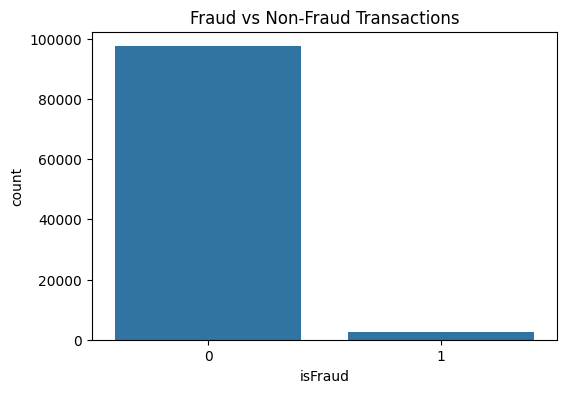

In [58]:
expected_files = ['train_transaction.csv', 'train_identity.csv']
if not all((DATA_DIR / f).exists() for f in expected_files):
    try:
        import kagglehub
        import shutil
        print('Downloading dataset via kagglehub...')
        path = kagglehub.dataset_download('lnasiri007/ieeecis-fraud-detection')
        for f in expected_files:
            for candidate in Path(path).rglob(f):
                shutil.copy(candidate, DATA_DIR / f)
                print(f'Copied {f} -> {DATA_DIR}')
                break
    except Exception as e:
        print('Download failed. Ensure you are logged in to Kaggle:', e)

else:
    print('data already loaded in the data folder')
# Load full dataset (default for Colab)
print(f'Loading train_transaction.csv (nrows={NROWS})...')
transaction = pd.read_csv(DATA_DIR / 'train_transaction.csv', low_memory=False, nrows=NROWS)
print('Transaction shape:', transaction.shape)

print('Loading train_identity.csv...')
identity = pd.read_csv(DATA_DIR / 'train_identity.csv', low_memory=False)
print('Identity shape:', identity.shape)

print('Merging transaction + identity...')
df = transaction.merge(identity, on='TransactionID', how='left')
print('Merged shape:', df.shape)
del transaction, identity
gc.collect()

# Run EDA
target = 'isFraud'
fraud_count = int(df[target].sum())
total_count = len(df)
print(f'Total transactions : {total_count:,}')
print(f'Fraud transactions  : {fraud_count:,}')
print(f'Fraud percentage    : {fraud_count/total_count*100:.2f}%')

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target)
plt.title('Fraud vs Non-Fraud Transactions')
plt.savefig(PLOT_DIR / 'fraud_distribution.png')
plt.show()

## 3. Feature Engineering

In [59]:
print('Engineering time features...')
seconds_per_day = 24 * 60 * 60
df['transaction_day'] = df['TransactionDT'] // seconds_per_day
df['transaction_hour'] = (df['TransactionDT'] % seconds_per_day) // 3600
df['transaction_weekday'] = df['transaction_day'] % 7
df['is_night'] = ((df['transaction_hour'] < 6) | (df['transaction_hour'] >= 23)).astype('int8')

print('Engineering traditional features...')
if 'TransactionAmt' in df.columns:
    df['log_transaction_amount'] = np.log1p(df['TransactionAmt'].clip(lower=0))
card_columns = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']
existing_cards = [col for col in card_columns if col in df.columns]
if existing_cards:
    df['card_missing_count'] = df[existing_cards].isna().sum(axis=1)

print('Engineering behavioral features...')
df = df.sort_values('TransactionDT').reset_index(drop=True)
card_parts = [col for col in ['card1', 'card2', 'card3', 'card5', 'card6'] if col in df.columns]
if card_parts:
    df['card_key'] = df[card_parts].astype('string').fillna('UNKNOWN').agg('_'.join, axis=1)
else:
    df['card_key'] = df['TransactionID'].astype(str)

df['previous_card_amount'] = df.groupby('card_key')['TransactionAmt'].shift(1)
shifted_amt = df.groupby('card_key')['TransactionAmt'].shift(1)
df['card_previous_mean_amount'] = shifted_amt.groupby(df['card_key']).cumsum() / (shifted_amt.groupby(df['card_key']).cumcount() + 1)
df['card_previous_transaction_count'] = df.groupby('card_key').cumcount()
df['amount_deviation_ratio'] = df['TransactionAmt'] / (df['card_previous_mean_amount'] + 1e-6)

if 'DeviceInfo' in df.columns:
    df['device_key'] = df['DeviceInfo'].astype('string').fillna('UNKNOWN')
    df['card_device_key'] = df['card_key'].astype(str) + '_' + df['device_key'].astype(str)
    df['card_device_previous_count'] = df.groupby('card_device_key').cumcount()
    df['is_new_card_device'] = (df['card_device_previous_count'] == 0).astype('int8')
else:
    df['is_new_card_device'] = 0

df['card_previous_transaction_time'] = df.groupby('card_key')['TransactionDT'].shift(1)
df['seconds_since_previous_card_transaction'] = df['TransactionDT'] - df['card_previous_transaction_time']
df['rapid_transaction'] = df['seconds_since_previous_card_transaction'].between(0, 300).fillna(False).astype('int8')
df['very_rapid_transaction'] = df['seconds_since_previous_card_transaction'].between(0, 60).fillna(False).astype('int8')

df['amount_anomaly'] = np.log1p(df['amount_deviation_ratio'].clip(lower=0)).clip(upper=5) / 5
df['new_card_behavior'] = (df['card_previous_transaction_count'] == 0).astype('int8')
df['velocity_behavior'] = 0.7 * df['rapid_transaction'] + 0.3 * df['very_rapid_transaction']

df['behavioral_risk_score'] = (
    0.35 * df['amount_anomaly'].fillna(0) +
    0.25 * df['is_new_card_device'] +
    0.20 * df['velocity_behavior'] +
    0.20 * df['is_night']
)
df['behavioral_risk_score'] = df['behavioral_risk_score'].clip(0, 1)

# Prepare final feature matrix X and label vector y
drop_columns = [target, 'TransactionID', 'TransactionDT', 'card_key', 'card_device_key', 'device_key', 'card_previous_transaction_time']
drop_columns = [col for col in drop_columns if col in df.columns]
X = df.drop(columns=drop_columns)
y = df[target].astype(int)

categorical_columns = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
for col in categorical_columns:
    freq = X[col].value_counts(dropna=False, normalize=True)
    X[col + '_freq'] = X[col].map(freq).fillna(0)
X = X.drop(columns=categorical_columns)
X = X.replace([np.inf, -np.inf], np.nan)

for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        X[col] = pd.to_numeric(X[col], errors='coerce')
    if pd.api.types.is_float_dtype(X[col]):
        X[col] = X[col].astype(np.float32)
    elif pd.api.types.is_integer_dtype(X[col]):
        X[col] = X[col].astype(np.int32)

missing_ratio = X.isna().mean()
keep_columns = missing_ratio[missing_ratio < 0.95].index
X = X[keep_columns]
print('Final feature shape:', X.shape)

Engineering time features...
Engineering traditional features...
Engineering behavioral features...
Final feature shape: (100000, 443)


## 4. Temporal Splitting & Imputation

In [60]:
from sklearn.impute import SimpleImputer

print('Splitting dataset chronologically...')
order = np.argsort(df['TransactionDT'].values)
X = X.iloc[order].reset_index(drop=True)
y = y.iloc[order].reset_index(drop=True)

split_point = int(len(X) * 0.80)
X_train = X.iloc[:split_point].copy()
X_valid = X.iloc[split_point:].copy()
y_train = y.iloc[:split_point].copy()
y_valid = y.iloc[split_point:].copy()
print('Training shape:', X_train.shape)
print('Validation shape:', X_valid.shape)

print('Imputing missing values...')
imputer = SimpleImputer(strategy='mean')
X_train_processed = imputer.fit_transform(X_train)
X_valid_processed = imputer.transform(X_valid)
print('Imputation completed successfully.')

Splitting dataset chronologically...
Training shape: (80000, 443)
Validation shape: (20000, 443)
Imputing missing values...
Imputation completed successfully.


## 5. Baseline Model Training & Evaluation

Scale positive weight: 36.65
Baseline XGBoost model trained.

Baseline XGBoost metrics:
  ROC-AUC:     0.89509
  PR-AUC:      0.58762
  Precision:   0.31148
  Recall:      0.65367
  F1 Score:    0.42191


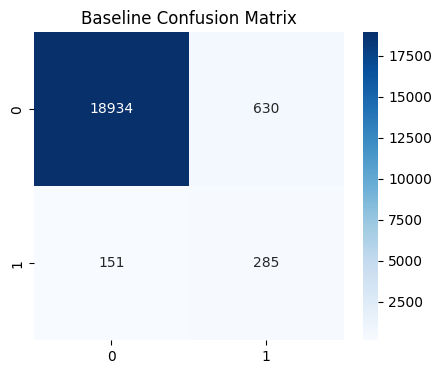

In [61]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, brier_score_loss, confusion_matrix

fraud_count = int(y_train.sum())
normal_count = len(y_train) - fraud_count
scale_pos_weight = normal_count / max(fraud_count, 1)
print('Scale positive weight:', round(scale_pos_weight, 2))

baseline_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.80,
    colsample_bytree=0.80,
    objective='binary:logistic',
    eval_metric='aucpr',
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist'
)
baseline_model.fit(X_train_processed, y_train)
print('Baseline XGBoost model trained.')

# Evaluate baseline
baseline_probability = baseline_model.predict_proba(X_valid_processed)[:, 1]
baseline_prediction = (baseline_probability >= 0.5).astype(int)

print('\nBaseline XGBoost metrics:')
print(f'  ROC-AUC:     {roc_auc_score(y_valid, baseline_probability):.5f}')
print(f'  PR-AUC:      {average_precision_score(y_valid, baseline_probability):.5f}')
print(f'  Precision:   {precision_score(y_valid, baseline_prediction, zero_division=0):.5f}')
print(f'  Recall:      {recall_score(y_valid, baseline_prediction, zero_division=0):.5f}')
print(f'  F1 Score:    {f1_score(y_valid, baseline_prediction, zero_division=0):.5f}')

# Plot confusion matrix
cm = confusion_matrix(y_valid, baseline_prediction)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.savefig(PLOT_DIR / 'baseline_confusion_matrix.png')
plt.show()

## 6. SMOTE Resampling & Behavior-Aware Model

Applying SMOTE resampling...
After SMOTE — Fraud: 15,575  Normal: 77,875
Behavior-aware XGBoost model trained.

Behavior-Aware XGBoost metrics:
  ROC-AUC:     0.90960
  PR-AUC:      0.61024
  Precision:   0.85470
  Recall:      0.45872
  F1 Score:    0.59701


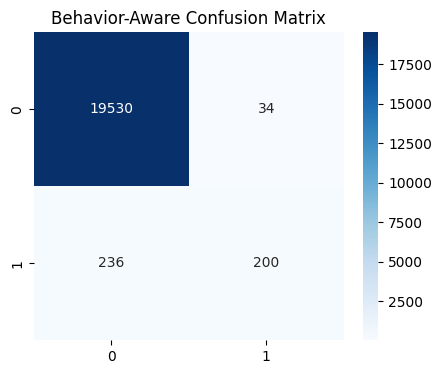

In [62]:
from imblearn.over_sampling import SMOTE

print('Applying SMOTE resampling...')
smote = SMOTE(sampling_strategy=0.20, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)
print(f'After SMOTE — Fraud: {y_train_smote.sum():,}  Normal: {(y_train_smote==0).sum():,}')

improved_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist'
)
improved_model.fit(X_train_smote, y_train_smote)
print('Behavior-aware XGBoost model trained.')

improved_probability = improved_model.predict_proba(X_valid_processed)[:, 1]
improved_prediction = (improved_probability >= 0.5).astype(int)

print('\nBehavior-Aware XGBoost metrics:')
print(f'  ROC-AUC:     {roc_auc_score(y_valid, improved_probability):.5f}')
print(f'  PR-AUC:      {average_precision_score(y_valid, improved_probability):.5f}')
print(f'  Precision:   {precision_score(y_valid, improved_prediction, zero_division=0):.5f}')
print(f'  Recall:      {recall_score(y_valid, improved_prediction, zero_division=0):.5f}')
print(f'  F1 Score:    {f1_score(y_valid, improved_prediction, zero_division=0):.5f}')

cm = confusion_matrix(y_valid, improved_prediction)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Behavior-Aware Confusion Matrix')
plt.savefig(PLOT_DIR / 'behavior_confusion_matrix.png')
plt.show()

## 7. Threshold Optimization & Anomaly Detection

In [63]:
from sklearn.ensemble import IsolationForest

print('Optimizing F1 classification threshold...')
results = []
for threshold in np.arange(0.05, 0.96, 0.05):
    prediction = (improved_probability >= threshold).astype(int)
    results.append({
        'threshold': threshold,
        'precision': precision_score(y_valid, prediction, zero_division=0),
        'recall': recall_score(y_valid, prediction, zero_division=0),
        'f1': f1_score(y_valid, prediction, zero_division=0)
    })
threshold_df = pd.DataFrame(results)
best_row = threshold_df.loc[threshold_df['f1'].idxmax()]
best_threshold = float(best_row['threshold'])
print(f'Best threshold: {best_threshold:.2f} (F1: {best_row["f1"]:.4f})')
threshold_df.to_csv(REPORT_DIR / 'threshold_analysis.csv', index=False)

print('\nTraining Isolation Forest anomaly model...')
normal_indices = np.where(y_train.values == 0)[0]
sample_size = min(100000, len(normal_indices))
rng = np.random.default_rng(RANDOM_STATE)
selected_indices = rng.choice(normal_indices, size=sample_size, replace=False)

anomaly_model = IsolationForest(n_estimators=100, contamination='auto', random_state=RANDOM_STATE, n_jobs=-1)
anomaly_model.fit(X_train_processed[selected_indices])
print('Isolation Forest trained.')

# Calculate normalized anomaly score
raw_score = -anomaly_model.score_samples(X_valid_processed)
anomaly_score = (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min() + 1e-8)
anomaly_score = np.clip(anomaly_score, 0, 1)

# Get behavioral risk score slice
split_point = int(len(df) * 0.80)
behavior_score = df['behavioral_risk_score'].iloc[split_point:].fillna(0).values

Optimizing F1 classification threshold...
Best threshold: 0.35 (F1: 0.6188)

Training Isolation Forest anomaly model...
Isolation Forest trained.


## 8. Model Checkpointing

In [64]:
print('Saving trained models and thresholds...')
joblib.dump(imputer, MODEL_DIR / 'imputer.pkl')
joblib.dump(baseline_model, MODEL_DIR / 'baseline_xgboost.pkl')
joblib.dump(improved_model, MODEL_DIR / 'behavior_aware_xgboost.pkl')
joblib.dump(anomaly_model, MODEL_DIR / 'isolation_forest.pkl')
joblib.dump(best_threshold, MODEL_DIR / 'optimal_threshold.pkl')
joblib.dump(list(X.columns), MODEL_DIR / 'feature_names.pkl')
print('All model checkpoints saved successfully!')

Saving trained models and thresholds...
All model checkpoints saved successfully!


## 9. Final Hybrid Scoring & Results

FINAL HYBRID RESULTS:
  ROC-AUC:     0.85412
  PR-AUC:      0.58106
  Precision:   0.78832
  Recall:      0.49541
  F1 Score:    0.60845
  Brier Score: 0.01617

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99     19564
       Fraud       0.79      0.50      0.61       436

    accuracy                           0.99     20000
   macro avg       0.89      0.75      0.80     20000
weighted avg       0.98      0.99      0.98     20000



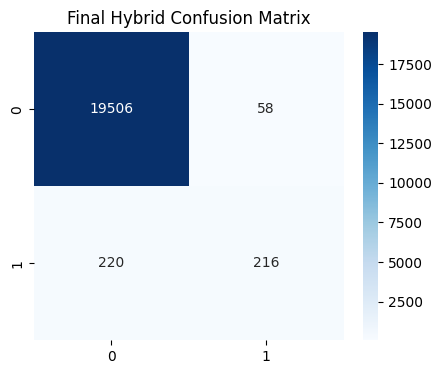

In [65]:
from sklearn.metrics import classification_report

# Align lengths
min_length = min(len(improved_probability), len(behavior_score), len(anomaly_score))
improved_probability = improved_probability[:min_length]
behavior_score = behavior_score[:min_length]
anomaly_score = anomaly_score[:min_length]
y_valid_final = y_valid.iloc[:min_length]

# Calculate final hybrid risk score
final_risk_score = 0.70 * improved_probability + 0.20 * behavior_score + 0.10 * anomaly_score
final_prediction = (final_risk_score >= best_threshold).astype(int)

print('FINAL HYBRID RESULTS:')
print(f'  ROC-AUC:     {roc_auc_score(y_valid_final, final_risk_score):.5f}')
print(f'  PR-AUC:      {average_precision_score(y_valid_final, final_risk_score):.5f}')
print(f'  Precision:   {precision_score(y_valid_final, final_prediction, zero_division=0):.5f}')
print(f'  Recall:      {recall_score(y_valid_final, final_prediction, zero_division=0):.5f}')
print(f'  F1 Score:    {f1_score(y_valid_final, final_prediction, zero_division=0):.5f}')
print(f'  Brier Score: {brier_score_loss(y_valid_final, final_risk_score):.5f}')

print('\nClassification Report:')
print(classification_report(y_valid_final, final_prediction, target_names=['Legitimate', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_valid_final, final_prediction)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Final Hybrid Confusion Matrix')
plt.savefig(PLOT_DIR / 'final_confusion_matrix.png')
plt.show()

## 10. Model Explainability (SHAP)

Running SHAP analysis...


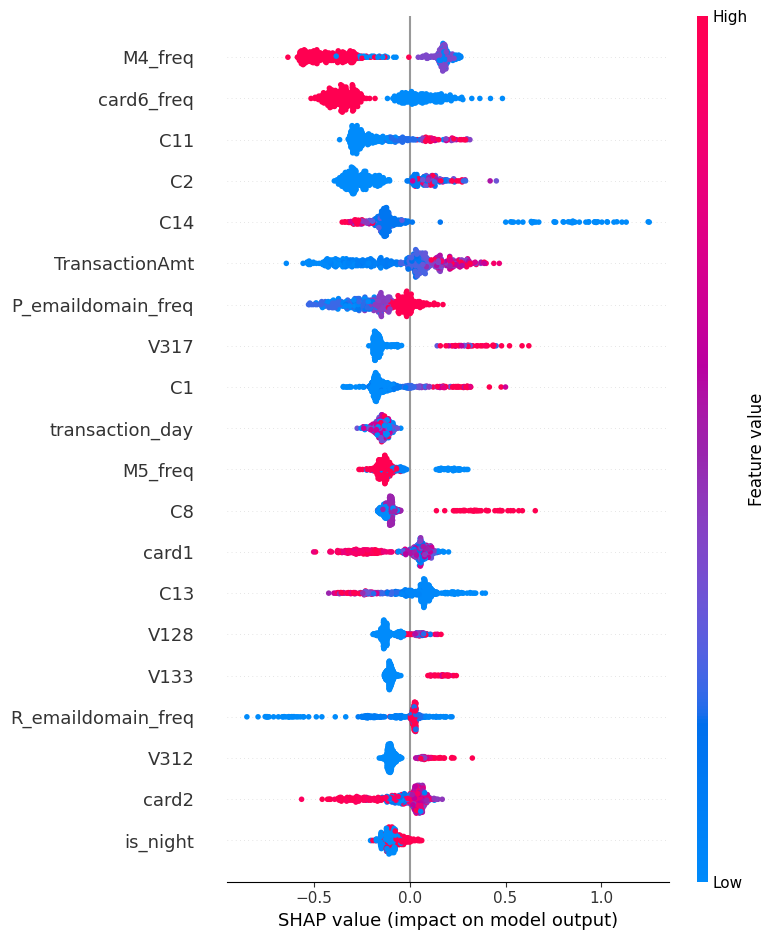

In [66]:
import shap

print('Running SHAP analysis...')
sample_size = min(500, len(X_valid_processed))
rng = np.random.default_rng(RANDOM_STATE)
indices = rng.choice(len(X_valid_processed), size=sample_size, replace=False)
X_sample = X_valid_processed[indices]

try:
    explainer = shap.TreeExplainer(improved_model)
    shap_values = explainer.shap_values(X_sample)
    plt.figure()
    shap.summary_plot(shap_values, X_sample, feature_names=X.columns, show=False)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'shap_summary.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print('SHAP could not be completed:', e)

## 11. Save Deployment Configurations

In [67]:
import json

print('Saving config metadata JSON...')
configuration = {
    'dataset': 'lnasiri007/ieeecis-fraud-detection',
    'random_state': RANDOM_STATE,
    'optimal_threshold': best_threshold,
    'behavior_weights': {
        'amount_anomaly': 0.35,
        'device_novelty': 0.25,
        'velocity': 0.20,
        'night_behavior': 0.20
    },
    'final_risk_weights': {
        'xgboost': 0.70,
        'behavior': 0.20,
        'anomaly': 0.10
    }
}
with open(REPORT_DIR / 'configuration.json', 'w') as file:
    json.dump(configuration, file, indent=4)
print('Configuration JSON saved to:', REPORT_DIR / 'configuration.json')

Saving config metadata JSON...
Configuration JSON saved to: D:\projects\Fraud detection\reports\configuration.json
